# Preprocesado de variables con máscaras NPY

Este notebook usa `io.py` simplificado y máscaras guardadas en convención del pipeline: **latitude ascendente (-90 -> 90)**, **longitude ascendente (-180 -> 180)**.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

import src.data.io as io

In [2]:
# Rutas
raw_dir = Path("/home/dani/github/profecia/data/raw")
processed_base_dir = Path("/home/dani/github/profecia/data/processed")
mask_dir = Path("/home/dani/github/profecia/data/masks")

# Variables
VARIABLE_NAMES = ["LAI", "SM1", "SM2", "TP", "T2M", "SSRD", "VPD"]

# Configuración
temporal_resolution = "annual"   # "monthly" o "annual"
start_year = 1982
end_year_inclusive = 2022
dtype = "float32"
roi = None

# Máscaras activas: cualquier subconjunto de ["land", "ebf", "bs", "climate", "landcover"]
mask_names = ["land", "ebf", "bs"]
save_output = True

In [3]:
def normalize_mask_names(mask_names):
    mask_names = [m.lower().strip() for m in mask_names]
    invalid = [m for m in mask_names if m not in io.MASK_MAP]
    if invalid:
        raise ValueError(f"Máscaras no soportadas: {invalid}. Disponibles: {list(io.MASK_MAP)}")
    return mask_names


def build_run_name(mask_names, temporal_resolution):
    tokens = mask_names[:] if mask_names else ["nomask"]
    tokens.append(temporal_resolution.lower())
    return "_".join(tokens)

In [4]:
mask_names = normalize_mask_names(mask_names)
run_name = build_run_name(mask_names, temporal_resolution)

output_dir = processed_base_dir / run_name
output_dir.mkdir(parents=True, exist_ok=True)

print("Run name:", run_name)
print("Output dir:", output_dir)
print("Máscaras activas:", mask_names if mask_names else ["nomask"])

Run name: land_ebf_bs_annual
Output dir: /home/dani/github/profecia/data/processed/land_ebf_bs_annual
Máscaras activas: ['land', 'ebf', 'bs']


In [5]:
# Cargamos LAI raw solo para comprobar grid y visualizar máscaras
lai_raw, _ = io.load_netcdf(
    base_dir=raw_dir,
    variable="LAI",
    roi=roi,
    start_year=start_year,
    end_year_inclusive=end_year_inclusive,
    dtype=dtype,
)

latitude = lai_raw["latitude"].values
longitude = lai_raw["longitude"].values

print("Grid:")
print("  latitude:", float(latitude.min()), "->", float(latitude.max()), "|", len(latitude))
print("  longitude:", float(longitude.min()), "->", float(longitude.max()), "|", len(longitude))
print("  time:", str(lai_raw.time.values[0])[:10], "->", str(lai_raw.time.values[-1])[:10])

Grid:
  latitude: -90.0 -> 89.5 | 360
  longitude: -180.0 -> 179.5 | 720
  time: 1982-01-01 -> 2022-12-01


In [6]:
masks = {
    name: io.load_mask(mask_dir, name, latitude, longitude)
    for name in mask_names
}

print("Máscaras cargadas:", list(masks.keys()))
for name, da in masks.items():
    print(name, da.shape, da.dtype)

Máscaras cargadas: ['land', 'ebf', 'bs']
land (360, 720) uint8
ebf (360, 720) uint8
bs (360, 720) uint8


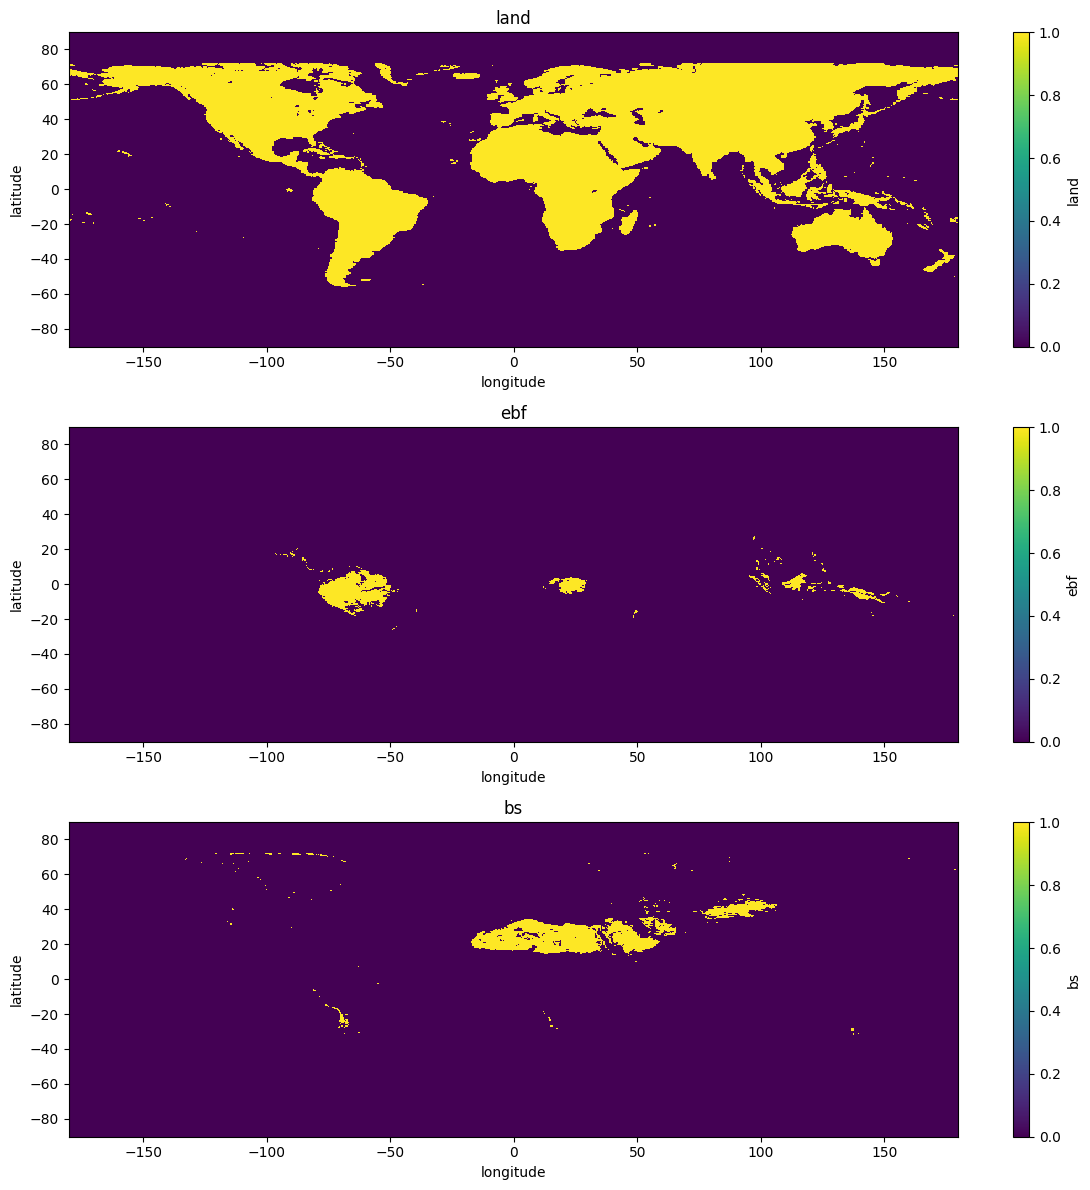

In [7]:
if masks:
    fig, axes = plt.subplots(len(masks), 1, figsize=(12, 4 * len(masks)))
    if len(masks) == 1:
        axes = [axes]

    for ax, (name, da) in zip(axes, masks.items()):
        da.plot(ax=ax)
        ax.set_title(name)

    plt.tight_layout()
    plt.show()

In [8]:
lai_ref = io.aggregate_time(
    da=lai_raw,
    variable_name="LAI",
    temporal_resolution=temporal_resolution,
)

combined_mask, mask_info = io.build_combined_filter_mask(
    da=lai_ref,
    masks=masks if masks else None,
)

mask_info

{'mask_names': ['land', 'ebf', 'bs'],
 'combined_pixels_kept': 55060,
 'combined_total_pixels': 259200,
 'combined_fraction_kept': 0.21242283950617283}

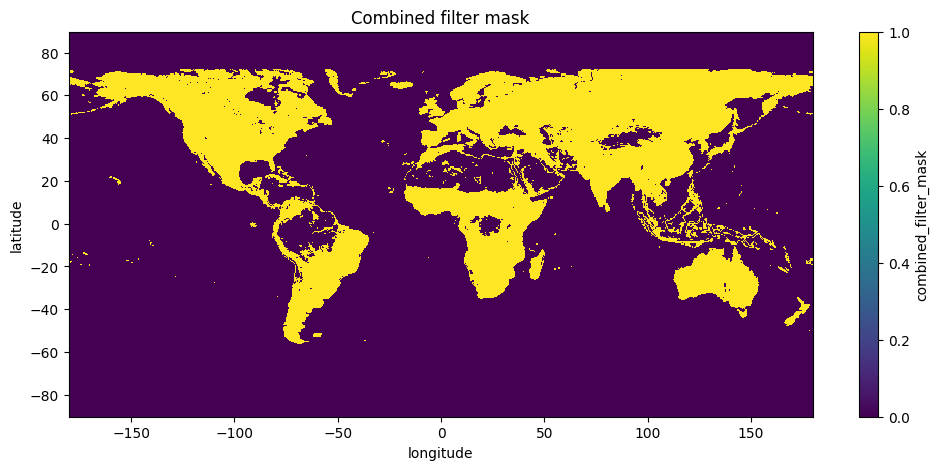

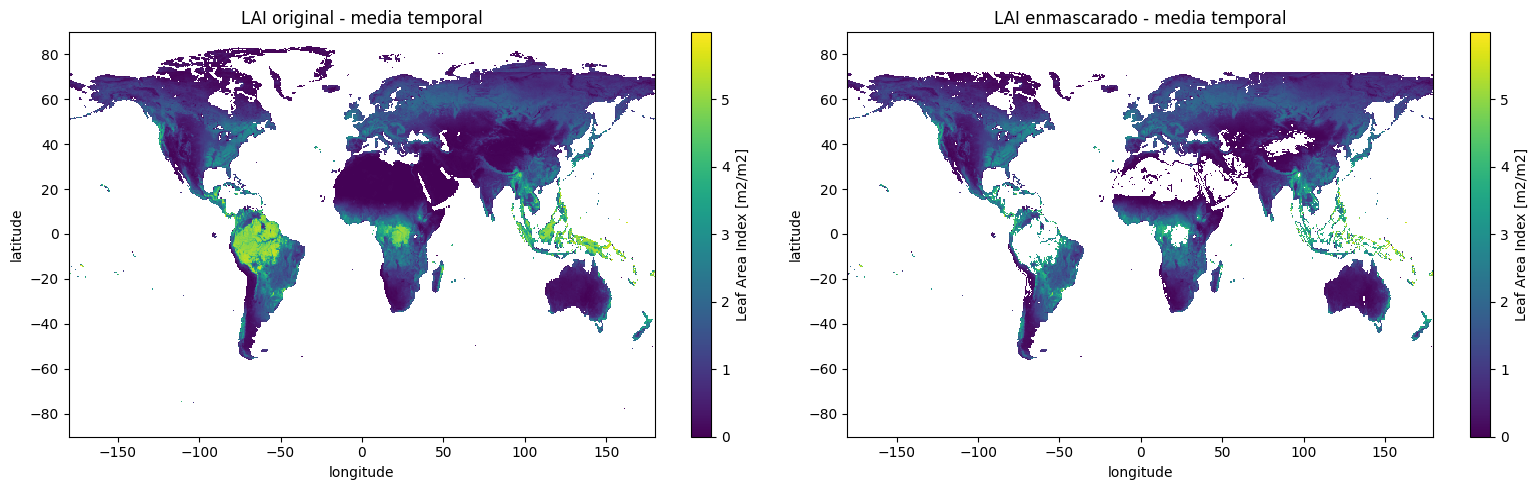

In [9]:
if combined_mask is not None:
    combined_mask.astype(int).plot(figsize=(12, 5))
    plt.title("Combined filter mask")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    lai_ref.mean(dim="time", skipna=True).plot(ax=axes[0], cmap="viridis")
    axes[0].set_title("LAI original - media temporal")
    lai_ref.where(combined_mask).mean(dim="time", skipna=True).plot(ax=axes[1], cmap="viridis")
    axes[1].set_title("LAI enmascarado - media temporal")
    plt.tight_layout()
    plt.show()

In [10]:
results = {}

for var in VARIABLE_NAMES:
    print(f"Procesando {var} ...")
    results[var] = io.load_and_save_variable(
        raw_dir=raw_dir,
        output_dir=output_dir,
        variable=var,
        mask_dir=mask_dir,
        mask_names=mask_names,
        roi=roi,
        start_year=start_year,
        end_year_inclusive=end_year_inclusive,
        dtype=dtype,
        temporal_resolution=temporal_resolution,
        save_output=save_output,
    )

print("Variables procesadas:", list(results))

Procesando LAI ...
Procesando SM1 ...
Procesando SM2 ...
Procesando TP ...
Procesando T2M ...
Procesando SSRD ...
Procesando VPD ...
Variables procesadas: ['LAI', 'SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD']


In [11]:
io.save_processed_metadata(
    output_dir=output_dir,
    variable_results=results,
    temporal_resolution=temporal_resolution,
    roi=roi,
    start_year=start_year,
    end_year_inclusive=end_year_inclusive,
    dtype=dtype,
)

run_config = {
    "run_name": run_name,
    "output_dir": str(output_dir),
    "raw_dir": str(raw_dir),
    "mask_dir": str(mask_dir),
    "temporal_resolution": temporal_resolution,
    "start_year": start_year,
    "end_year_inclusive": end_year_inclusive,
    "dtype": dtype,
    "roi": io._to_jsonable(roi),
    "variable_names": VARIABLE_NAMES,
    "mask_names": mask_names,
    "mask_files": {name: str(mask_dir / io.MASK_MAP[name]) for name in mask_names},
    "combined_filter_info": mask_info,
}

with open(output_dir / "run_config.json", "w", encoding="utf-8") as f:
    json.dump(io._to_jsonable(run_config), f, ensure_ascii=False, indent=2)

print("metadata.json guardado en:", output_dir / "metadata.json")
print("run_config.json guardado en:", output_dir / "run_config.json")

metadata.json guardado en: /home/dani/github/profecia/data/processed/land_ebf_bs_annual/metadata.json
run_config.json guardado en: /home/dani/github/profecia/data/processed/land_ebf_bs_annual/run_config.json


In [12]:
print("Run terminado.")
print("Output dir:", output_dir)
for var in VARIABLE_NAMES:
    print(f"- {var}: {results[var]['array_path']}")

Run terminado.
Output dir: /home/dani/github/profecia/data/processed/land_ebf_bs_annual
- LAI: /home/dani/github/profecia/data/processed/land_ebf_bs_annual/LAI.npy
- SM1: /home/dani/github/profecia/data/processed/land_ebf_bs_annual/SM1.npy
- SM2: /home/dani/github/profecia/data/processed/land_ebf_bs_annual/SM2.npy
- TP: /home/dani/github/profecia/data/processed/land_ebf_bs_annual/TP.npy
- T2M: /home/dani/github/profecia/data/processed/land_ebf_bs_annual/T2M.npy
- SSRD: /home/dani/github/profecia/data/processed/land_ebf_bs_annual/SSRD.npy
- VPD: /home/dani/github/profecia/data/processed/land_ebf_bs_annual/VPD.npy
